In [1]:
!pip install tensorflow

In [2]:
#Bibliotecas
import tensorflow as tf
import keras
import matplotlib
import numpy as np

In [3]:
tf.__version__, keras.__version__, matplotlib.__version__, np.__version__

('2.16.1', '3.13.2', '3.10.0', '1.26.4')

In [4]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, Dense, Flatten, Dropout,Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras import utils as np_utils
import matplotlib.pyplot as plt

In [5]:
(X_treinamento, y_treinamento), (X_teste, y_teste) = mnist.load_data()

In [6]:
X_treinamento.shape, X_teste.shape # verificando a quantidade de digitos utilizados para o treinamento e para os testes

((60000, 28, 28), (10000, 28, 28))

In [7]:
28 * 28 # calculo de pixels de cada imagem

784

In [8]:
X_treinamento # exibe

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [9]:
X_treinamento, X_treinamento.max() # comparando os valores

(array([[[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        ...,
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],

In [10]:
y_treinamento

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

Text(0.5, 1.0, 'Classe 5')

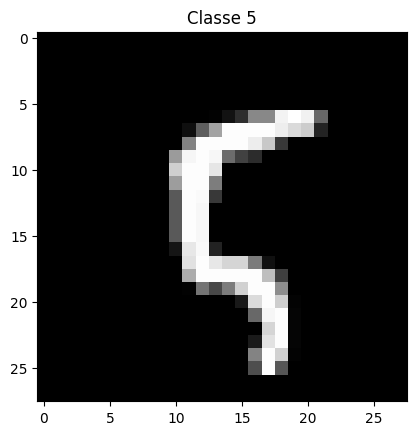

In [11]:
plt.imshow(X_treinamento[100], cmap='gray') # mostra a primeira imagem
plt.title('Classe ' + str(y_treinamento[100])) # titulo com a classe

In [12]:
X_treinamento.shape

(60000, 28, 28)

In [13]:
X_treinamento = X_treinamento.reshape(X_treinamento.shape[0], 28, 28, 1) # colocando na primeira posição a quantidade de imagens, as dimensões e a quantidade de canais da imagem

In [14]:
X_teste = X_teste.reshape(X_teste.shape[0], 28, 28, 1) # colocando na primeira posição a quantidade de imagens, as dimensões e a quantidade de canais da imagem

In [15]:
X_treinamento.shape # foi adicionado o canal, pois como as cores variam apenas de preto a branco não necessita dos tres canais(RGB)

(60000, 28, 28, 1)

In [16]:
X_teste.shape # foi adicionado o canal, pois como as cores variam apenas de preto a branco não necessita dos tres canais(RGB)

(10000, 28, 28, 1)

In [17]:
X_treinamento = X_treinamento.astype('float32') # definindo o tipo float 32

In [18]:
X_teste = X_teste.astype('float32') # definindo o tipo float 32

In [19]:
X_treinamento /= 255 # dividindo cada valor com 255(valor max)

In [20]:
X_teste /= 255 # dividindo cada valor com 255(valor max)

In [21]:
X_treinamento.max(), X_treinamento.min() # exibi o valor max e o min

(1.0, 0.0)

In [22]:
y_treinamento

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [23]:
y_treinamento = np_utils.to_categorical(y_treinamento, 10) # transformando em categorias
y_teste = np_utils.to_categorical(y_teste, 10) # transformando em categorias

In [24]:
y_treinamento

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]])

In [25]:
y_treinamento[2] # exibi apenas a posicao 2

array([0., 0., 0., 0., 1., 0., 0., 0., 0., 0.])

In [36]:
rede_neural = Sequential() # criando a rede neural
rede_neural.add(InputLayer(shape=(28, 28, 1))) # adicionando a camada de entrada


rede_neural.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu')) # adicionando a primeira camada convolucional
rede_neural.add(BatchNormalization()) # camada para aplicar um processamento
rede_neural.add(MaxPooling2D(pool_size=(2,2))) # adicionando a camada de pooling

rede_neural.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu')) # adicionando a primeira camada convolucional
rede_neural.add(BatchNormalization()) # camada para aplicar um processamento
rede_neural.add(MaxPooling2D(pool_size=(2,2))) # adicionando a camada de pooling

rede_neural.add(Flatten()) # transforma matriz em vetor

rede_neural.add(Dense(units=128, activation='relu')) # adcionando a camada oculta
rede_neural.add(Dropout(0.2)) # camada para zerar 20%
rede_neural.add(Dense(units=128, activation='relu')) # adcionando a camada oculta
rede_neural.add(Dropout(0.2)) # camada para zerar 20%

rede_neural.add(Dense(units=10, activation='softmax')) # adicionando a camada de saida

In [27]:
13 * 13 * 32 # calculo do flatten, que vão para camada de entrada

5408

In [28]:
(5408 + 10) / 2 # essa formula não é utilizada

2709.0

In [37]:
rede_neural.summary() # mostra o resumo da rede neural

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       102,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,154 (508.41 KB)

 Trainable params: 130,026 (507.91 KB)

 Non-trainable params: 128 (512.00 B)

In [38]:
rede_neural.compile(loss = 'categorical_crossentropy', optimizer= 'adam', metrics = ['accuracy'])

In [39]:
rede_neural.fit(X_treinamento, y_treinamento, batch_size= 128, epochs=5, validation_data = (X_teste, y_teste)) # treinamento

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 45s 93ms/step - accuracy: 0.9288 - loss: 0.2315 - val_accuracy: 0.9507 - val_loss: 0.1648
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 42s 90ms/step - accuracy: 0.9806 - loss: 0.0631 - val_accuracy: 0.9868 - val_loss: 0.0476
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 42s 90ms/step - accuracy: 0.9865 - loss: 0.0458 - val_accuracy: 0.9893 - val_loss: 0.0376
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 88ms/step - accuracy: 0.9889 - loss: 0.0380 - val_accuracy: 0.9908 - val_loss: 0.0347
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 39s 84ms/step - accuracy: 0.9910 - loss: 0.0304 - val_accuracy: 0.9909 - val_loss: 0.0355


In [40]:
resultado = rede_neural.evaluate(X_teste, y_teste) # avaliando o modelo

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9909 - loss: 0.0355


In [41]:
resultado # exibi o accuracy e o loss

[0.03554024547338486, 0.9908999800682068]